# 16. Error Analysis by Segment and Use Case

A model can post respectable overall metrics and still fail exactly where the decision is most consequential. This notebook studies that problem directly. We will train a support-risk model that looks reasonable in aggregate, then show how **segment-level auditing** reveals a hidden operational slice with concentrated false negatives.

## Learning Objectives

By the end of this notebook, you should be able to:

1. Explain why aggregate error hides segment-level risk.
2. Compute conditional performance metrics for slices that matter operationally.
3. Distinguish threshold-free model quality from threshold-dependent decision quality.
4. Use case review to move from "the model is wrong here" to "the system should change in this way."
5. Translate an error audit into concrete redesign choices for features, monitoring, and intervention policy.

## 1. Core Mathematical Ideas

Let $f(X)$ be a model score and let $\ell(\hat{y}, y)$ be a loss function. The **overall risk** is

$$
R(f) = \mathbb{E}[\ell(f(X), Y)].
$$

If $G$ indexes a subgroup or operational slice, then the **slice-conditional risk** is

$$
R_g(f) = \mathbb{E}[\ell(f(X), Y) \mid G = g].
$$

When the slices form a partition of the evaluation population,

$$
R(f) = \sum_g \Pr(G=g)\,R_g(f).
$$

This averaging is exactly why a model can look fine overall while behaving poorly in a rare but important slice. A small slice can contribute little to $R(f)$ even if its own error is severe.

For decision systems, threshold-based diagnostics are equally important. Given a score threshold $t$,

$$
\text{Recall}_g(t) = \Pr\big(f(X) \ge t \mid Y=1, G=g\big),
$$

$$
\text{Precision}_g(t) = \Pr\big(Y=1 \mid f(X) \ge t, G=g\big),
$$

$$
\text{FNR}_g(t) = 1 - \text{Recall}_g(t).
$$

The key lesson is simple. **model evaluation is not finished when you compute AUC**. We also need to ask where the misses concentrate and whether those misses occur in the exact slice where intervention matters most.

In [1]:
# Section focus: 1. Core Mathematical Ideas.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)


def logistic(x):
    """Carry out the logistic step used in the 16. Error Analysis by Segment and Use Case workflow.
    
    Parameters
    ----------
    x : object
        Numeric score, scalar, or array passed through the transformation in this helper.
    
    Returns
    -------
    object
        Intermediate result produced by the logistic calculation and reused by later cells.
    """
    return 1 / (1 + np.exp(-x))

from matplotlib.patches import Patch


## 2. Operational Setting and a Hidden Failure Slice

We will simulate a seller-support operation. Each row is one seller-day. The target is whether that day ends in an SLA breach. Importantly, the model is asked to score cases **before same-day workflow disruptions are fully logged**.

That detail matters. We will introduce a rare event called `workflow_migration_today`: a same-day systems migration that increases complexity, queue pressure, and breach risk. It is real and operationally important, but it is **not available in the morning feature set** used for prediction. This creates the kind of hidden slice that often appears in production systems.

In [2]:
# Section focus: 2. Operational Setting and a Hidden Failure Slice.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def simulate_support_operations(n_sellers=180, n_days=150, random_state=2026):
    """Create a simulated support operations data set for the 16. Error Analysis by Segment and Use Case case study.
    
    Parameters
    ----------
    n_sellers : object
        Count or size setting for the support operations calculation.
    n_days : object
        Count or size setting for the support operations calculation.
    random_state : object
        Random seed or generator control used to make results reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(random_state)

    seller_ids = np.arange(n_sellers)
    tiers = rng.choice(["SMB", "Mid-Market", "Enterprise"], size=n_sellers, p=[0.5, 0.32, 0.18])
    regions = rng.choice(["North America", "Europe", "APAC"], size=n_sellers, p=[0.46, 0.29, 0.25])
    channels = rng.choice(["Email", "Chat", "Phone"], size=n_sellers, p=[0.45, 0.35, 0.20])
    analyst_experience = np.clip(rng.normal(4.8, 1.6, size=n_sellers), 0.5, 10.0)
    base_risk = rng.normal(0.0, 1.0, size=n_sellers)
    migration_prone = rng.binomial(1, 0.28, size=n_sellers)

    pressure_state = rng.normal(0.0, 0.6, size=n_sellers)
    backlog_state = np.clip(rng.normal(4.5, 1.3, size=n_sellers), 1.0, 10.0)

    dates = pd.date_range("2025-01-01", periods=n_days, freq="D")
    records = []

    for day_idx, date in enumerate(dates):
        weekday = date.weekday()
        weekend = int(weekday >= 5)
        release_window = int(day_idx % 28 in [5, 6, 7])

        for seller_idx, seller_id in enumerate(seller_ids):
            tier = tiers[seller_idx]
            region = regions[seller_idx]
            channel = channels[seller_idx]
            experience = analyst_experience[seller_idx]
            seller_risk = base_risk[seller_idx]
            prior_pressure = pressure_state[seller_idx]
            prior_backlog = backlog_state[seller_idx]

            enterprise = int(tier == "Enterprise")
            apac = int(region == "APAC")
            email = int(channel == "Email")

            current_pressure = (
                0.93 * prior_pressure
                + rng.normal(0.0, 0.18)
                + 0.16 * weekend
                + 0.20 * release_window
                + 0.08 * seller_risk
            )

            migration_probability = min(
                0.01
                + 0.05 * migration_prone[seller_idx]
                + 0.03 * enterprise
                + 0.02 * apac
                + 0.05 * release_window,
                0.35,
            )
            workflow_migration_today = rng.binomial(1, migration_probability)

            tickets_mean = np.exp(
                1.0
                + 0.22 * seller_risk
                + 0.34 * current_pressure
                + 0.08 * prior_backlog
                + 0.08 * email
                + 0.38 * workflow_migration_today
            )
            tickets_opened = rng.poisson(min(tickets_mean, 20))

            queue_load = max(
                0.5,
                3.6
                + 1.0 * tickets_opened
                + 1.4 * max(current_pressure, 0)
                + 0.35 * prior_backlog
                + rng.normal(0.0, 0.8),
            )

            resolved_capacity = 3.8 + 0.35 * experience + rng.normal(0.0, 0.7)
            backlog_end = max(
                0.0,
                0.74 * prior_backlog + 0.38 * tickets_opened - resolved_capacity + rng.normal(0.0, 0.4),
            )

            resolution_minutes = max(
                12.0,
                45
                + 2.2 * tickets_opened
                + 7.0 * max(current_pressure, 0)
                + 1.8 * prior_backlog
                + 5.0 * enterprise
                + 3.0 * apac
                + 4.0 * seller_risk
                - 1.6 * experience
                + 14.0 * workflow_migration_today
                + rng.normal(0.0, 4.5),
            )

            breach_logit = (
                -2.9
                + 0.60 * seller_risk
                + 0.95 * current_pressure
                + 0.05 * tickets_opened
                + 0.12 * prior_backlog
                + 0.008 * resolution_minutes
                + 0.95 * workflow_migration_today
                + 0.10 * release_window
                + 0.12 * apac
                - 0.10 * experience
            )
            sla_breach = rng.binomial(1, logistic(breach_logit))

            records.append(
                {
                    "seller_id": seller_id,
                    "date": date,
                    "tier": tier,
                    "region": region,
                    "channel": channel,
                    "analyst_experience": experience,
                    "tickets_opened": tickets_opened,
                    "queue_load": queue_load,
                    "backlog_end": backlog_end,
                    "resolution_minutes": resolution_minutes,
                    "sla_breach": sla_breach,
                    "workflow_migration_today": workflow_migration_today,
                    "release_window": release_window,
                    "weekday": weekday,
                }
            )

            pressure_state[seller_idx] = 0.90 * current_pressure + 0.20 * sla_breach + 0.03 * (queue_load / 10)
            backlog_state[seller_idx] = np.clip(0.84 * prior_backlog + 0.16 * backlog_end, 0.0, 18.0)

    return pd.DataFrame(records)


def build_feature_matrix(df):
    """Build the feature matrix object used in the 16. Error Analysis by Segment and Use Case analysis.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    feature_df = df.sort_values(["seller_id", "date"]).copy()
    grouped = feature_df.groupby("seller_id", group_keys=False)

    feature_df["prior_backlog"] = grouped["backlog_end"].shift(1)
    feature_df["prior_queue_load"] = grouped["queue_load"].shift(1)
    feature_df["prior_tickets"] = grouped["tickets_opened"].shift(1)

    feature_df["backlog_7d_mean"] = grouped["backlog_end"].shift(1).rolling(7, min_periods=2).mean().reset_index(level=0, drop=True)
    feature_df["queue_7d_mean"] = grouped["queue_load"].shift(1).rolling(7, min_periods=2).mean().reset_index(level=0, drop=True)
    feature_df["tickets_7d_mean"] = grouped["tickets_opened"].shift(1).rolling(7, min_periods=2).mean().reset_index(level=0, drop=True)
    feature_df["breach_rate_7d"] = grouped["sla_breach"].shift(1).rolling(7, min_periods=2).mean().reset_index(level=0, drop=True)
    feature_df["resolution_7d_mean"] = grouped["resolution_minutes"].shift(1).rolling(7, min_periods=2).mean().reset_index(level=0, drop=True)

    feature_df["recent_backlog_jump"] = feature_df["prior_backlog"] - feature_df["backlog_7d_mean"]
    feature_df["queue_pressure_gap"] = feature_df["prior_queue_load"] - feature_df["queue_7d_mean"]

    feature_df["weekday_sin"] = np.sin(2 * np.pi * feature_df["weekday"] / 7)
    feature_df["weekday_cos"] = np.cos(2 * np.pi * feature_df["weekday"] / 7)

    feature_df = feature_df.dropna().reset_index(drop=True)
    return feature_df


ops = simulate_support_operations()
feature_df = build_feature_matrix(ops)
feature_df.head()

,seller_id,date,tier,region,channel,analyst_experience,tickets_opened,queue_load,backlog_end,resolution_minutes,sla_breach,workflow_migration_today,release_window,weekday,prior_backlog,prior_queue_load,prior_tickets,backlog_7d_mean,queue_7d_mean,tickets_7d_mean,breach_rate_7d,resolution_7d_mean,recent_backlog_jump,queue_pressure_gap,weekday_sin,weekday_cos
0,0,2025-01-02,SMB,Europe,Chat,4.4241,2,5.729420,0.0,53.659543,0,0,0,3,0.0,8.305605,3.0,0.0,5.196699,1.714286,0.000000,34.541237,0.0,3.108906,0.433884,-0.900969
1,0,2025-01-03,SMB,Europe,Chat,4.4241,2,6.519198,0.0,48.489730,0,0,0,4,0.0,5.729420,2.0,0.0,8.216899,3.571429,0.000000,52.444300,0.0,-2.487479,-0.433884,-0.900969
2,0,2025-01-04,SMB,Europe,Chat,4.4241,9,13.447958,0.0,64.831400,0,0,0,5,0.0,6.519198,2.0,0.0,6.573365,2.571429,0.000000,42.046094,0.0,-0.054167,-0.974928,-0.222521
3,0,2025-01-05,SMB,Europe,Chat,4.4241,5,11.256500,0.0,62.266226,1,0,0,6,0.0,13.447958,9.0,0.0,8.034066,2.857143,0.428571,50.440066,0.0,5.413892,-0.781831,0.623490
4,0,2025-01-06,SMB,Europe,Chat,4.4241,8,13.741675,0.0,66.951135,1,0,1,0,0.0,11.256500,5.0,0.0,6.691423,2.166667,0.000000,43.349222,0.0,4.565077,0.000000,1.000000


In Operational Setting and a Hidden Failure Slice, the point of the output is practical. The analyst should be able to say what the result changes.


,quantity,value
0,Rows,"26,820"
1,Sellers,180
2,Evaluation span,2025-01-02 to 2025-05-30
3,Overall breach rate,22.7%
4,Workflow migration share,4.0%
5,Breach rate during workflow migration,37.7%


,slice,case_share,breach_rate,avg_resolution_minutes
0,No migration,0.96044,0.220389,55.142840
1,Workflow migration,0.03956,0.377003,74.084909


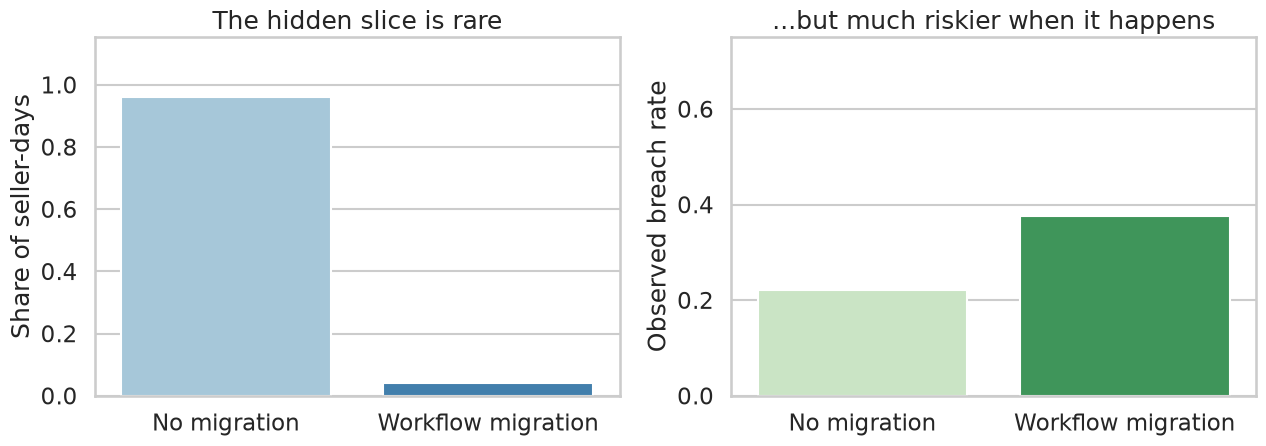

In [3]:
# Section focus: 2. Operational Setting and a Hidden Failure Slice.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

overview = pd.DataFrame(
    [
        {"quantity": "Rows", "value": f"{len(feature_df):,}"},
        {"quantity": "Sellers", "value": feature_df['seller_id'].nunique()},
        {"quantity": "Evaluation span", "value": f"{feature_df['date'].min().date()} to {feature_df['date'].max().date()}"},
        {"quantity": "Overall breach rate", "value": f"{feature_df['sla_breach'].mean():.1%}"},
        {"quantity": "Workflow migration share", "value": f"{feature_df['workflow_migration_today'].mean():.1%}"},
        {
            "quantity": "Breach rate during workflow migration",
            "value": f"{feature_df.loc[feature_df['workflow_migration_today'] == 1, 'sla_breach'].mean():.1%}",
        },
    ]
)

display(overview)

slice_summary = (
    feature_df.groupby("workflow_migration_today")
    .agg(
        case_share=("sla_breach", "size"),
        breach_rate=("sla_breach", "mean"),
        avg_resolution_minutes=("resolution_minutes", "mean"),
    )
    .reset_index()
)
slice_summary["case_share"] = slice_summary["case_share"] / slice_summary["case_share"].sum()
slice_summary["slice"] = slice_summary["workflow_migration_today"].map({0: "No migration", 1: "Workflow migration"})
display(slice_summary[["slice", "case_share", "breach_rate", "avg_resolution_minutes"]])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.barplot(data=slice_summary, x="slice", y="case_share", palette=["#9ecae1", "#3182bd"], ax=axes[0])
axes[0].set_title("The hidden slice is rare")
axes[0].set_ylabel("Share of seller-days")
axes[0].set_xlabel("")
axes[0].set_ylim(0, max(0.08, slice_summary["case_share"].max() * 1.2))

sns.barplot(data=slice_summary, x="slice", y="breach_rate", palette=["#c7e9c0", "#31a354"], ax=axes[1])
axes[1].set_title("...but much riskier when it happens")
axes[1].set_ylabel("Observed breach rate")
axes[1].set_xlabel("")
axes[1].set_ylim(0, max(0.75, slice_summary["breach_rate"].max() * 1.15))

plt.tight_layout()
plt.show()

In a real deployment, we would not know this slice so cleanly ahead of time. The point of the simulation is to create a controlled version of a common operational problem: a system disruption is real, consequential, and unevenly distributed, but the feature pipeline the model sees does not yet represent it.

## 3. Fit a Chronology-Respecting Baseline

We will use a logistic model with lagged operational features only. That is deliberate. The point of this notebook is not to win a leaderboard. It is to show how an apparently reasonable production-style baseline can still hide dangerous misses.

Notice what the feature set excludes: there is no same-day `workflow_migration_today` flag. The model gets yesterday's backlog, yesterday's queue pressure, recent breach history, seller segment, and calendar structure, but it does **not** get the disruptive event itself.

In [4]:
# Section focus: 3. Fit a Chronology-Respecting Baseline.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def split_train_test(df, test_fraction=0.15):
    """Carry out the split train test step used in the 16. Error Analysis by Segment and Use Case workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    test_fraction : object
        Test split or held-out value used by this workflow.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    ordered_dates = np.sort(df["date"].unique())
    n_test_dates = int(np.ceil(len(ordered_dates) * test_fraction))
    test_dates = ordered_dates[-n_test_dates:]
    train_df = df.loc[~df["date"].isin(test_dates)].copy()
    test_df = df.loc[df["date"].isin(test_dates)].copy()
    return train_df, test_df


feature_cols = [
    "tier",
    "region",
    "channel",
    "analyst_experience",
    "prior_backlog",
    "prior_queue_load",
    "prior_tickets",
    "backlog_7d_mean",
    "queue_7d_mean",
    "tickets_7d_mean",
    "breach_rate_7d",
    "resolution_7d_mean",
    "recent_backlog_jump",
    "queue_pressure_gap",
    "weekday_sin",
    "weekday_cos",
]

categorical_features = ["tier", "region", "channel"]
numeric_features = [col for col in feature_cols if col not in categorical_features]

train_df, test_df = split_train_test(feature_df)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_features,
        ),
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
    ]
)

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(C=0.0316, max_iter=2000)),
    ]
)

baseline_model.fit(train_df[feature_cols], train_df["sla_breach"])

test_scored = test_df.copy()
test_scored["score"] = baseline_model.predict_proba(test_df[feature_cols])[:, 1]
test_scored.head()

,seller_id,date,tier,region,channel,analyst_experience,tickets_opened,queue_load,backlog_end,resolution_minutes,sla_breach,workflow_migration_today,release_window,weekday,prior_backlog,prior_queue_load,prior_tickets,backlog_7d_mean,queue_7d_mean,tickets_7d_mean,breach_rate_7d,resolution_7d_mean,recent_backlog_jump,queue_pressure_gap,weekday_sin,weekday_cos,score
126,0,2025-05-08,SMB,Europe,Chat,4.4241,6,11.226094,0.0,64.107109,1,0,0,3,0.0,8.839466,2.0,0.730387,17.650821,10.285714,1.000000,91.646500,-0.730387,-8.811356,0.433884,-0.900969,0.240099
127,0,2025-05-09,SMB,Europe,Chat,4.4241,2,6.269042,0.0,53.762939,0,0,0,4,0.0,11.226094,6.0,0.317711,18.820914,11.428571,1.000000,88.238551,-0.317711,-7.594821,-0.433884,-0.900969,0.233326
128,0,2025-05-10,SMB,Europe,Chat,4.4241,6,11.474715,0.0,58.350735,0,0,0,5,0.0,6.269042,2.0,0.000000,5.762015,2.000000,0.142857,44.263566,0.000000,0.507027,-0.974928,-0.222521,0.087668
129,0,2025-05-11,SMB,Europe,Chat,4.4241,14,19.422920,0.0,80.194793,1,0,0,6,0.0,11.474715,6.0,0.000000,7.407195,2.833333,0.000000,44.572434,0.000000,4.067520,-0.781831,0.623490,0.263359
130,0,2025-05-12,SMB,Europe,Chat,4.4241,5,8.930928,0.0,61.313078,0,0,0,0,0.0,19.422920,14.0,0.000000,6.225924,2.000000,0.000000,45.960943,0.000000,13.196996,0.000000,1.000000,0.647491


Fit a Chronology-Respecting Baseline gives a checkpoint for the decision workflow. Let the pattern guide the next modeling or review choice.


## 4. Aggregate Performance Can Still Mislead

Overall discrimination is useful, but it is only the opening diagnostic. If the model is intended to trigger triage or escalation, then a stakeholder should immediately ask a second question: **which kinds of cases are being missed?**

This emphasis is aligned with work on hidden stratification and algorithmic audits. Aggregate metrics can obscure clinically or operationally meaningful subgroup failures, and structured error analysis is part of responsible deployment practice (Oakden-Rayner et al., 2020; Liu et al., 2022).

,metric,value
0,ROC AUC,0.799206
1,Average precision,0.608213
2,Brier score,0.129383
3,Observed breach rate,0.223430
4,Average predicted risk,0.215395


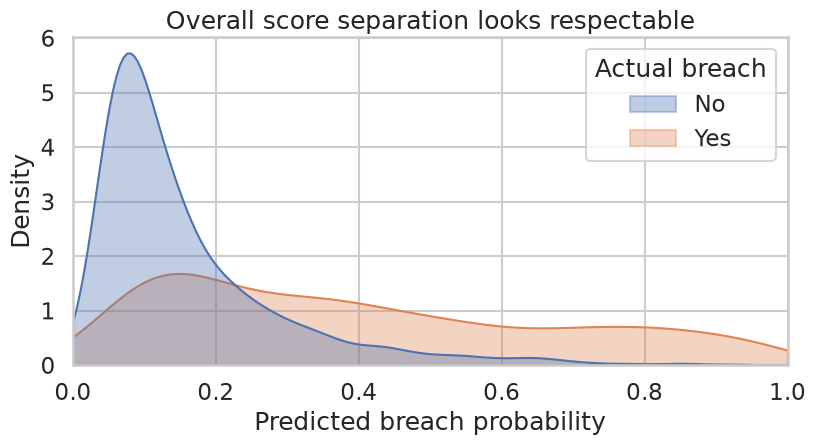

In [5]:
# Section focus: 4. Aggregate Performance Can Still Mislead.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def safe_auc(y_true, score):
    """Carry out the safe auc step used in the 16. Error Analysis by Segment and Use Case workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    score : object
        Single score, risk value, or diagnostic value used by the decision rule.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the safe auc calculation.
    """
    if pd.Series(y_true).nunique() < 2:
        return np.nan
    return roc_auc_score(y_true, score)


def safe_ap(y_true, score):
    """Carry out the safe ap step used in the 16. Error Analysis by Segment and Use Case workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    score : object
        Single score, risk value, or diagnostic value used by the decision rule.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the safe ap calculation.
    """
    if pd.Series(y_true).nunique() < 2:
        return np.nan
    return average_precision_score(y_true, score)


overall_metrics = pd.DataFrame(
    [
        {"metric": "ROC AUC", "value": safe_auc(test_scored["sla_breach"], test_scored["score"])},
        {"metric": "Average precision", "value": safe_ap(test_scored["sla_breach"], test_scored["score"])},
        {"metric": "Brier score", "value": brier_score_loss(test_scored["sla_breach"], test_scored["score"])},
        {"metric": "Observed breach rate", "value": test_scored["sla_breach"].mean()},
        {"metric": "Average predicted risk", "value": test_scored["score"].mean()},
    ]
)

display(overall_metrics)

plot_scores = test_scored.assign(actual_breach=test_scored["sla_breach"].map({0: "No", 1: "Yes"}))
palette = {"No": "#4c72b0", "Yes": "#dd8452"}

fig, ax = plt.subplots(figsize=(8.5, 4.8))
sns.kdeplot(
    data=plot_scores,
    x="score",
    hue="actual_breach",
    hue_order=["No", "Yes"],
    palette=palette,
    fill=True,
    common_norm=False,
    alpha=0.35,
    clip=(0, 1),
    legend=False,
    ax=ax,
)
ax.set_title("Overall score separation looks respectable")
ax.set_xlabel("Predicted breach probability")
ax.set_ylabel("Density")
ax.set_xlim(0, 1)
ax.legend(
    handles=[
        Patch(facecolor=palette["No"], edgecolor=palette["No"], alpha=0.35, label="No"),
        Patch(facecolor=palette["Yes"], edgecolor=palette["Yes"], alpha=0.35, label="Yes"),
    ],
    title="Actual breach",
)
plt.tight_layout()
plt.show()

A plot like this is exactly where teams are tempted to stop. The scores separate positives from negatives reasonably well, and the average predicted risk is close to the observed event rate. But none of that tells us whether the misses cluster in a segment the intervention policy actually cares about.

## 5. Segment-Level Diagnostics at a Triage Threshold

Suppose the operation can review only the highest-risk fifth of seller-days. We will define a **broad triage queue** by flagging the top 20% of predicted scores.

This is where threshold-free and threshold-dependent evaluation part ways. A model can have acceptable AUC while still delivering poor recall in the slice where missed breaches are most costly.

,segment,n,breach_rate,avg_score,auc,average_precision,precision,recall,fnr,flag_rate
0,All cases,4140,0.223430,0.215395,0.799206,0.608213,0.594203,0.531892,0.468108,0.200000
1,Workflow migration,162,0.370370,0.216547,0.746242,0.683076,0.735294,0.416667,0.583333,0.209877
2,No migration,3978,0.217446,0.215348,0.802798,0.607668,0.588161,0.539884,0.460116,0.199598
3,Enterprise,621,0.291465,0.276524,0.812142,0.740495,0.647059,0.607735,0.392265,0.273752
4,SMB,2093,0.215002,0.201838,0.790312,0.565290,0.608815,0.491111,0.508889,0.173435
5,High workload,1035,0.520773,0.500603,0.742392,0.769115,0.605063,0.886827,0.113173,0.763285


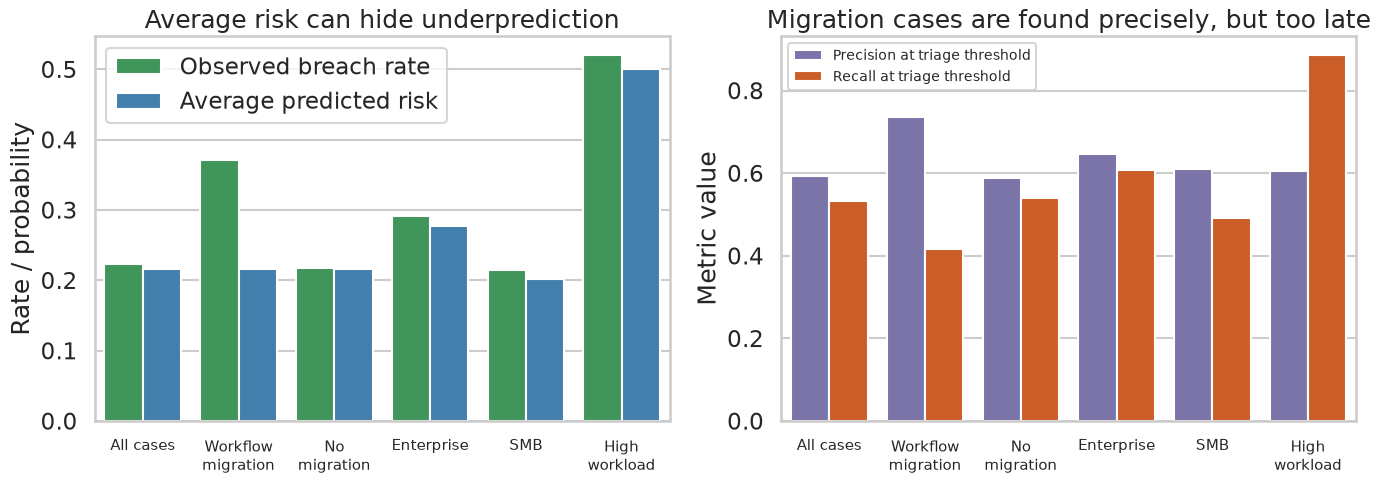

Triage threshold: 0.329
Share of missed breaches that come from workflow migration: 8.1%
Overall workflow migration share in the test set: 3.9%


In [6]:
# Section focus: 5. Segment-Level Diagnostics at a Triage Threshold.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def summarize_slice(df, mask, threshold, label):
    """Summarize slice for the 16. Error Analysis by Segment and Use Case analysis.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    mask : object
        The mask setting that controls the slice calculation in this notebook.
    threshold : object
        Decision cutoff used to convert scores into actions or alerts.
    label : object
        Human-readable label used to name a model, scenario, metric, or plotted series.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    subset = df.loc[mask].copy()
    y_true = subset["sla_breach"]
    y_score = subset["score"]
    y_pred = (y_score >= threshold).astype(int)

    return {
        "segment": label,
        "n": len(subset),
        "breach_rate": y_true.mean(),
        "avg_score": y_score.mean(),
        "auc": safe_auc(y_true, y_score),
        "average_precision": safe_ap(y_true, y_score),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "fnr": 1 - recall_score(y_true, y_pred, zero_division=0),
        "flag_rate": y_pred.mean(),
    }


triage_threshold = test_scored["score"].quantile(0.80)
high_workload_cutoff = test_scored["prior_queue_load"].quantile(0.75)

slice_definitions = [
    ("All cases", np.ones(len(test_scored), dtype=bool)),
    ("Workflow migration", test_scored["workflow_migration_today"] == 1),
    ("No migration", test_scored["workflow_migration_today"] == 0),
    ("Enterprise", test_scored["tier"] == "Enterprise"),
    ("SMB", test_scored["tier"] == "SMB"),
    ("High workload", test_scored["prior_queue_load"] >= high_workload_cutoff),
]

slice_metrics = pd.DataFrame(
    [summarize_slice(test_scored, mask, triage_threshold, label) for label, mask in slice_definitions]
)

display(slice_metrics)

plot_df = slice_metrics.copy()
plot_df["segment_short"] = [
    "All cases",
    "Workflow\nmigration",
    "No\nmigration",
    "Enterprise",
    "SMB",
    "High\nworkload",
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

comparison_df = plot_df.melt(
    id_vars="segment_short",
    value_vars=["breach_rate", "avg_score"],
    var_name="quantity",
    value_name="value",
)
comparison_labels = {"breach_rate": "Observed breach rate", "avg_score": "Average predicted risk"}
comparison_df["quantity"] = comparison_df["quantity"].map(comparison_labels)

sns.barplot(data=comparison_df, x="segment_short", y="value", hue="quantity", palette=["#31a354", "#3182bd"], ax=axes[0])
axes[0].set_title("Average risk can hide underprediction")
axes[0].set_xlabel("")
axes[0].set_ylabel("Rate / probability")
axes[0].legend(title="")

threshold_df = plot_df.melt(
    id_vars="segment_short",
    value_vars=["precision", "recall"],
    var_name="metric",
    value_name="value",
)
threshold_df["metric"] = threshold_df["metric"].map({"precision": "Precision at triage threshold", "recall": "Recall at triage threshold"})

sns.barplot(data=threshold_df, x="segment_short", y="value", hue="metric", palette=["#756bb1", "#e6550d"], ax=axes[1])
axes[1].set_title("Migration cases are found precisely, but too late")
axes[1].set_xlabel("")
axes[1].set_ylabel("Metric value")
axes[1].legend(title="", fontsize=10)

for ax in axes:
    ax.tick_params(axis="x", labelsize=11)

plt.tight_layout()
plt.show()

fn_migration_share = (
    test_scored.loc[(test_scored["sla_breach"] == 1) & (test_scored["score"] < triage_threshold), "workflow_migration_today"].mean()
)
print(f"Triage threshold: {triage_threshold:.3f}")
print(f"Share of missed breaches that come from workflow migration: {fn_migration_share:.1%}")
print(f"Overall workflow migration share in the test set: {test_scored['workflow_migration_today'].mean():.1%}")

This is the heart of the notebook.

The workflow-migration slice is small, but its breach rate is dramatically higher than its average predicted risk. Precision in that slice is high because when the model does flag a migration case, it is usually serious. The operational problem is recall: too many of those events remain below the triage threshold.

That pattern is exactly what a team should worry about in practice. A rare slice can look acceptable on an overall dashboard while quietly dominating the most painful misses.

## 6. Thresholds Depend on Use Case

Now we make the decision problem more explicit.

- **Broad triage queue:** top 30% of scores. This reflects a larger review team that can inspect many cases.
- **Scarce specialist escalation:** top 10% of scores. This reflects a tighter intervention budget.

Neither threshold is universally correct. The correct one depends on intervention capacity, downstream action cost, and the harm of a miss.

The two thresholds represent different experiments with the same score. The broad triage rule tests whether a larger queue can catch many emerging problems, while the scarce escalation rule tests whether the model can concentrate the most urgent cases into a small expert workflow. Both are plausible, but they answer different operating questions.

This is why threshold choice belongs with the use case. A score can rank accounts well and still fail the business if the threshold overwhelms reviewers, misses protected segments, or sends cases to the wrong intervention. The notebook treats thresholds as policy choices, not as afterthoughts.


,use_case,segment,threshold,flag_rate,precision,recall,fnr
0,Broad triage,All cases,0.233328,0.300000,0.483897,0.649730,0.350270
1,Broad triage,Workflow migration,0.233328,0.345679,0.607143,0.566667,0.433333
2,Broad triage,No migration,0.233328,0.298140,0.478078,0.655491,0.344509
3,Broad triage,High workload,0.233328,0.954589,0.538462,0.987013,0.012987
4,Specialist escalation,All cases,0.512281,0.100000,0.724638,0.324324,0.675676
5,Specialist escalation,Workflow migration,0.512281,0.080247,0.923077,0.200000,0.800000
6,Specialist escalation,No migration,0.512281,0.100804,0.718204,0.332948,0.667052
7,Specialist escalation,High workload,0.512281,0.400000,0.724638,0.556586,0.443414


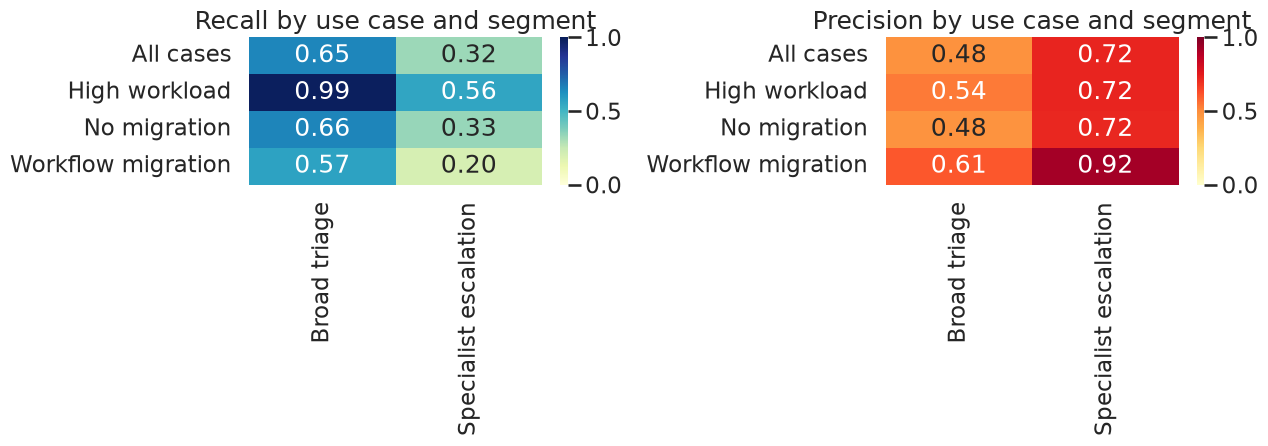

In [7]:
# Section focus: 6. Thresholds Depend on Use Case.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

use_case_thresholds = {
    "Broad triage": test_scored["score"].quantile(0.70),
    "Specialist escalation": test_scored["score"].quantile(0.90),
}

use_case_segments = [
    ("All cases", np.ones(len(test_scored), dtype=bool)),
    ("Workflow migration", test_scored["workflow_migration_today"] == 1),
    ("No migration", test_scored["workflow_migration_today"] == 0),
    ("High workload", test_scored["prior_queue_load"] >= high_workload_cutoff),
]

records = []
for use_case, threshold in use_case_thresholds.items():
    for label, mask in use_case_segments:
        metrics = summarize_slice(test_scored, mask, threshold, label)
        metrics["use_case"] = use_case
        metrics["threshold"] = threshold
        records.append(metrics)

use_case_df = pd.DataFrame(records)
display(use_case_df[["use_case", "segment", "threshold", "flag_rate", "precision", "recall", "fnr"]])

heatmap_recall = use_case_df.pivot(index="segment", columns="use_case", values="recall")
heatmap_precision = use_case_df.pivot(index="segment", columns="use_case", values="precision")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.heatmap(heatmap_recall, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1, ax=axes[0])
axes[0].set_title("Recall by use case and segment")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

sns.heatmap(heatmap_precision, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=1, ax=axes[1])
axes[1].set_title("Precision by use case and segment")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

The tradeoff is now visible. The scarce escalation threshold improves precision, but it usually worsens recall in the hidden slice. If the organization treats workflow migration as a must-catch event, then a single global threshold may be the wrong policy. Segment-aware intervention rules, workload-specific monitoring, or additional features may be necessary.

## 7. Error Auditing and Case Review

Numbers tell us **that** the model fails; case review helps explain **why**. Following the logic of error auditing, we now inspect the concrete false negatives and false positives produced by the broad triage rule (Oakden-Rayner et al., 2020; Liu et al., 2022).

The case review sample is intentionally small because the goal is close reading. Each false negative or false positive should be interpreted as a record with context: account segment, support load, usage change, prior escalation, and the action that would have followed. That is the level at which operational teams usually diagnose model failures.

This is also where real deployments become messier than the simulation. In production, labels may be delayed, reviewers may disagree, and some errors may only become visible after customer escalation. The notebook uses clean simulated labels to teach the audit workflow, while the lesson is that error analysis needs qualitative review as well as aggregate metrics.


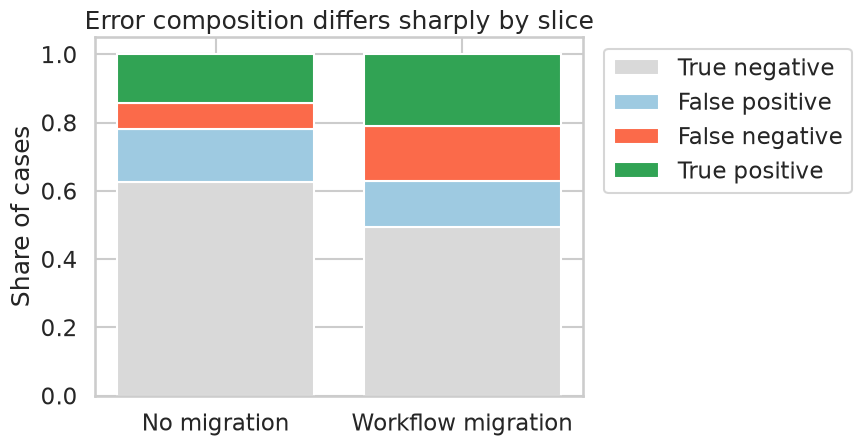

Missed breach cases inside the hidden workflow-migration slice


,date,seller_id,tier,region,channel,prior_backlog,queue_7d_mean,breach_rate_7d,score,resolution_minutes
10566,2025-05-18,70,Mid-Market,APAC,Chat,0.0,9.926643,0.142857,0.180100,112.751953
23669,2025-05-09,158,SMB,APAC,Chat,0.0,6.771958,0.000000,0.170212,86.725115
21737,2025-05-14,145,SMB,Europe,Email,0.0,10.493603,0.142857,0.120571,82.930840
9818,2025-05-15,65,Enterprise,North America,Email,0.0,4.860742,0.000000,0.207864,80.257530
26365,2025-05-23,176,Enterprise,North America,Chat,0.0,5.812411,0.142857,0.194823,78.468173
26818,2025-05-29,179,SMB,Europe,Chat,0.0,9.241614,0.428571,0.184827,76.765260
21142,2025-05-15,141,SMB,APAC,Email,0.0,5.533246,0.000000,0.080069,76.334945
6850,2025-05-27,45,SMB,North America,Chat,0.0,9.425700,0.142857,0.144884,75.892993


High-score cases that were reviewed but did not breach


,date,seller_id,tier,region,channel,prior_backlog,queue_7d_mean,breach_rate_7d,score,resolution_minutes
22049,2025-05-28,147,SMB,Europe,Email,0.900533,7.783732,0.000000,0.943571,113.233837
1477,2025-05-18,9,SMB,North America,Email,0.306207,9.039457,0.000000,0.932495,90.587096
1486,2025-05-27,9,SMB,North America,Email,1.064798,11.961251,0.428571,0.921238,89.100115
7140,2025-05-19,47,SMB,APAC,Chat,1.293429,6.636785,0.142857,0.912315,96.978999
1470,2025-05-11,9,SMB,North America,Email,2.673372,6.927244,0.000000,0.883038,111.881114
22045,2025-05-24,147,SMB,Europe,Email,0.470529,13.748152,0.714286,0.867091,93.900916
22050,2025-05-29,147,SMB,Europe,Email,2.343588,7.429999,0.142857,0.855679,95.505032
9677,2025-05-23,64,Enterprise,North America,Email,0.000000,5.612779,0.000000,0.853784,105.103398


In [8]:
# Section focus: 7. Error Auditing and Case Review.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

test_scored["triage_flag"] = (test_scored["score"] >= use_case_thresholds["Broad triage"]).astype(int)

test_scored["error_type"] = np.select(
    [
        (test_scored["sla_breach"] == 1) & (test_scored["triage_flag"] == 1),
        (test_scored["sla_breach"] == 1) & (test_scored["triage_flag"] == 0),
        (test_scored["sla_breach"] == 0) & (test_scored["triage_flag"] == 1),
    ],
    ["True positive", "False negative", "False positive"],
    default="True negative",
)

error_mix = (
    test_scored.groupby(["workflow_migration_today", "error_type"]).size().reset_index(name="count")
)
error_mix["migration_status"] = error_mix["workflow_migration_today"].map({0: "No migration", 1: "Workflow migration"})
error_mix["share"] = error_mix.groupby("migration_status")["count"].transform(lambda x: x / x.sum())

error_order = ["True negative", "False positive", "False negative", "True positive"]
error_palette = {
    "True negative": "#d9d9d9",
    "False positive": "#9ecae1",
    "False negative": "#fb6a4a",
    "True positive": "#31a354",
}

pivot_mix = (
    error_mix.pivot(index="migration_status", columns="error_type", values="share")
    .reindex(columns=error_order)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(9, 4.8))
left = np.zeros(len(pivot_mix))
for label in error_order:
    values = pivot_mix[label].to_numpy()
    ax.bar(pivot_mix.index, values, bottom=left, label=label, color=error_palette[label])
    left += values

ax.set_title("Error composition differs sharply by slice")
ax.set_ylabel("Share of cases")
ax.set_xlabel("")
ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

missed_migration_cases = (
    test_scored.loc[
        (test_scored["workflow_migration_today"] == 1)
        & (test_scored["sla_breach"] == 1)
        & (test_scored["triage_flag"] == 0),
        [
            "date",
            "seller_id",
            "tier",
            "region",
            "channel",
            "prior_backlog",
            "queue_7d_mean",
            "breach_rate_7d",
            "score",
            "resolution_minutes",
        ],
    ]
    .sort_values(["resolution_minutes", "score"], ascending=[False, False])
    .head(8)
)

false_positive_cases = (
    test_scored.loc[
        (test_scored["workflow_migration_today"] == 0)
        & (test_scored["sla_breach"] == 0)
        & (test_scored["triage_flag"] == 1),
        [
            "date",
            "seller_id",
            "tier",
            "region",
            "channel",
            "prior_backlog",
            "queue_7d_mean",
            "breach_rate_7d",
            "score",
            "resolution_minutes",
        ],
    ]
    .sort_values("score", ascending=False)
    .head(8)
)

print("Missed breach cases inside the hidden workflow-migration slice")
display(missed_migration_cases)

print("High-score cases that were reviewed but did not breach")
display(false_positive_cases)

The false-negative table is especially informative. Many missed migration cases arrive with ordinary-looking lagged history, which is exactly why the morning model underestimates them. The false-positive table tells a different story: some non-breach cases still look risky because historical workload, queue pressure, and prior breach patterns are genuinely concerning. That is not necessarily a model bug; it can reflect a conservative intervention policy.

This distinction matters. Error analysis should separate:

1. **Missing information** problems, where the feature pipeline does not represent a critical driver.
2. **Threshold policy** problems, where the model score may be sensible but the action rule is poorly aligned to capacity.
3. **Irreducible uncertainty** problems, where even a richer model cannot fully eliminate overlap.

## 8. Redesign Decisions After the Audit

A useful audit does not stop at description. It should change what the team does next.

For this system, the natural redesign choices are:

1. **Add or log same-day operational disruption signals.** Release windows, migration flags, and early queue-spike indicators belong in the prediction pipeline if the score is meant to trigger intervention.
2. **Monitor slice metrics explicitly.** Overall AUC should not be the only production dashboard. Track recall, false-negative concentration, and breach lift for migration-like or high-workload slices.
3. **Differentiate action rules by use case.** A broad triage queue and a scarce escalation queue should not be judged by the same operating point.
4. **Use case review as a recurring workflow.** Review a small batch of false negatives and false positives after each model refresh. This is often where the next feature idea comes from.
5. **Document what the score does not know.** As Bhatt et al. (2020) emphasize for deployment settings, explanations are useful only when they are tied to stakeholder decisions. In this notebook, the most important explanation is not a coefficient plot; it is the operational fact that the model cannot see same-day migration events.

That last point is worth underlining: sometimes the most actionable model explanation is simply, "the feature pipeline is missing a driver that the operation cares about."

## References

- Bhatt, U., Xiang, A., Sharma, S., et al. (2020). *Explainable machine learning in deployment.* [https://doi.org/10.1145/3351095.3375624](https://doi.org/10.1145/3351095.3375624)
- Liu, X., Glocker, B., McCradden, M. D., et al. (2022). *The medical algorithmic audit.* *The Lancet Digital Health*, 4(5), e384-e397. [https://doi.org/10.1016/S2589-7500(22)00003-6](https://doi.org/10.1016/S2589-7500%2822%2900003-6)
- Oakden-Rayner, L., Dunnmon, J., Carneiro, G., et al. (2020). *Hidden stratification causes clinically meaningful failures in machine learning for medical imaging.* [https://doi.org/10.1145/3368555.3384468](https://doi.org/10.1145/3368555.3384468)
- Tosh, C., & Hsu, D. (2021). *Simple and near-optimal algorithms for hidden stratification and multi-group learning.* [https://doi.org/10.48550/arXiv.2112.12181](https://doi.org/10.48550/arXiv.2112.12181)
